<a href="https://colab.research.google.com/github/peemoshi/skillset-ml-internship/blob/main/week-3/3.1-tensorflow-keras-model/tensorflow_cnn_cifar10_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 3.1: TensorFlow/Keras Model**

This notebook rebuilds the CIFAR-10 CNN from Task 2.2 in TensorFlow/Keras and compares it against the PyTorch version. To keep the comparison fair, only the framework changes: the dataset, train/test split, preprocessing, architecture, optimizer, learning rate, batch size and epoch count are all untouched.

CIFAR-10 is loaded with its standard 50,000/10,000 train/test split, the same split used in PyTorch. Pixels are scaled to [-1, 1] to match the PyTorch Normalize(0.5, 0.5) transform, and labels are flattened to integers. A fixed random seed is set for reproducibility.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# match the PyTorch preprocessing: scale pixels to [-1, 1]
x_train = x_train.astype("float32") / 127.5 - 1.0
x_test = x_test.astype("float32") / 127.5 - 1.0

# labels come as shape (N, 1); flatten to (N,)
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape, y_test.shape)
print("GPU:", tf.config.list_physical_devices("GPU"))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 34s 0us/step
Train: (50000, 32, 32, 3) (50000,)
Test:  (10000, 32, 32, 3) (10000,)
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


The Keras model mirrors the PyTorch SimpleCNN layer for layer: two 3×3 convolution blocks (32 then 64 channels) with ReLU and 2×2 max-pooling, then a 128-unit dense layer and a 10-unit output layer of raw logits. The summary shows 545,098 parameters, identical to the PyTorch model.

In [2]:
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

The model is compiled with Adam (learning rate 0.001) and sparse categorical cross-entropy on logits, the Keras equivalents of the PyTorch optimizer and CrossEntropyLoss. It trains for 10 epochs with batch size 64, evaluating on the test set after each epoch, as in the PyTorch loop. Keras handles the training loop internally.

In [3]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

In [4]:
history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=10,
    validation_data=(x_test, y_test),
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5462 - loss: 1.2718 - val_accuracy: 0.6416 - val_loss: 1.0170
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6812 - loss: 0.9136 - val_accuracy: 0.6803 - val_loss: 0.9252
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7349 - loss: 0.7642 - val_accuracy: 0.6955 - val_loss: 0.9109
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7764 - loss: 0.6474 - val_accuracy: 0.6947 - val_loss: 0.9407
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8133 - loss: 0.5434 - val_accuracy: 0.7040 - val_loss: 0.9425
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8443 - loss: 0.4528 - val_accuracy: 0.7119 - val_loss: 0.9629
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8684 - loss: 0.3803 - val_accuracy: 0.7028 - val_loss: 1.0573
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8911 - loss: 0.3160 - val_accuracy: 0

The curves show the usual overfitting pattern. Training loss and accuracy keep improving, while validation loss bottoms out around epoch 3 and then rises, so the model starts memorizing the training data after the first few epochs.

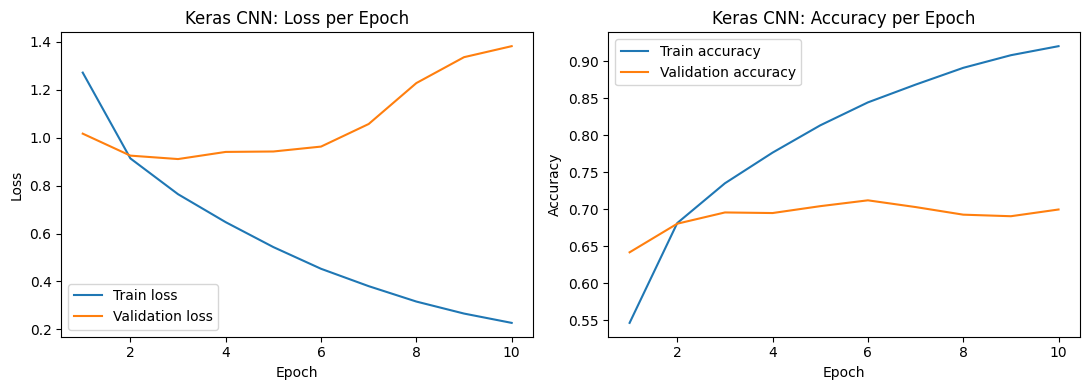

In [5]:
import matplotlib.pyplot as plt

epochs = range(1, 11)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, history.history["loss"], label="Train loss")
axes[0].plot(epochs, history.history["val_loss"], label="Validation loss")
axes[0].set_title("Keras CNN: Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs, history.history["accuracy"], label="Train accuracy")
axes[1].plot(epochs, history.history["val_accuracy"], label="Validation accuracy")
axes[1].set_title("Keras CNN: Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

The final model is evaluated on the held-out test set, saved in Keras' .keras format, and reloaded to confirm it reproduces the same accuracy (69.95%). Both the final-epoch and best-epoch accuracy are reported, since the best epoch is chosen using the test set and is slightly optimistic.

In [6]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final-epoch test accuracy: {test_acc:.4f}  |  test loss: {test_loss:.4f}")

best_val = max(history.history["val_accuracy"])
best_epoch = history.history["val_accuracy"].index(best_val) + 1
print(f"Best validation accuracy: {best_val:.4f} (epoch {best_epoch})")

model.save("cnn_cifar10_keras.keras")
reloaded = keras.models.load_model("cnn_cifar10_keras.keras")
re_loss, re_acc = reloaded.evaluate(x_test, y_test, verbose=0)
print(f"Reloaded model test accuracy: {re_acc:.4f}")

Final-epoch test accuracy: 0.6995  |  test loss: 1.3821
Best validation accuracy: 0.7119 (epoch 6)
Reloaded model test accuracy: 0.6995


Results vary with the random seed, since the seed controls both the initial weights and the batch order. To separate real differences from luck, the same Keras model is retrained with three more seeds.

In [7]:
def build_model():
    return keras.Sequential([
        keras.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10),
    ])

seed_results = []
for seed in [1, 2, 3]:
    tf.keras.utils.set_random_seed(seed)
    m = build_model()
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )
    h = m.fit(x_train, y_train, batch_size=64, epochs=10,
              validation_data=(x_test, y_test), verbose=0)
    final_acc = h.history["val_accuracy"][-1]
    best_acc = max(h.history["val_accuracy"])
    seed_results.append((seed, final_acc, best_acc))
    print(f"seed {seed}: final {final_acc:.4f} | best {best_acc:.4f}")

seed 1: final 0.6897 | best 0.7112
seed 2: final 0.6938 | best 0.7013
seed 3: final 0.6752 | best 0.7156


The table sets the PyTorch result from Task 2.2 next to all four Keras runs. Across seeds, Keras final-epoch accuracy averages about 69.0% (std ≈ 1.0 points) and best-epoch accuracy about 71.0% (std ≈ 0.6).

In [10]:
import pandas as pd

keras_final = [0.6995, 0.6897, 0.6938, 0.6752]   # seeds 42, 1, 2, 3
keras_best  = [0.7119, 0.7112, 0.7013, 0.7156]

rows = [
    ["PyTorch (Task 2.2), 1 run", 71.6, 72.7],
    ["Keras, seed 42", keras_final[0]*100, keras_best[0]*100],
    ["Keras, seed 1",  keras_final[1]*100, keras_best[1]*100],
    ["Keras, seed 2",  keras_final[2]*100, keras_best[2]*100],
    ["Keras, seed 3",  keras_final[3]*100, keras_best[3]*100],
    ["Keras mean", np.mean(keras_final)*100, np.mean(keras_best)*100],
    ["Keras std dev", np.std(keras_final, ddof=1)*100, np.std(keras_best, ddof=1)*100],
]

comparison = pd.DataFrame(rows, columns=["Run", "Final-epoch test acc (%)", "Best-epoch test acc (%)"]).round(2)
comparison

,Run,Final-epoch test acc (%),Best-epoch test acc (%)
0,"PyTorch (Task 2.2), 1 run",71.60,72.70
1,"Keras, seed 42",69.95,71.19
2,"Keras, seed 1",68.97,71.12
3,"Keras, seed 2",69.38,70.13
4,"Keras, seed 3",67.52,71.56
5,Keras mean,68.96,71.00
6,Keras std dev,1.04,0.61


**Comparison with PyTorch**

What was kept identical: dataset and split, preprocessing, architecture (545,098 parameters), optimizer and learning rate, batch size, and number of epochs.

Result: the PyTorch run scored 71.6% final-epoch and 72.7% best-epoch test accuracy. Across four seeds, Keras averaged 69.0% final-epoch and 71.0% best-epoch. The PyTorch run is higher than every Keras run on both measures, and by more than the seed-to-seed spread seen in Keras. Both models overfit after the first few epochs (Keras validation loss is lowest at epoch 3; PyTorch peaked around epochs 4–8), and Keras ended with a higher final test loss (about 1.38 vs. 1.10 for the seed-42 run).

Possible explanations: random variation (measured above), different default weight initialization (Glorot in Keras vs. Kaiming-style in PyTorch), a different default Adam epsilon (1e-7 vs. 1e-8), and different shuffling. This comparison cannot tell these apart.

Conclusion and limitations: PyTorch scored somewhat higher in this setup, but we cannot attribute that to the framework itself. Only one PyTorch run exists, so its own seed variance is unknown, and only default settings were compared. Both frameworks also monitored the test set during training rather than a separate validation set. A stronger comparison would repeat the PyTorch run across several seeds and align initialization and Adam epsilon.